In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import SimpleITK as sitk

from pathlib import Path

In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\Pancreatic_Cancer_Thesis


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk

PROJECT_ROOT = Path(r"D:\Pancreatic_Cancer_Thesis")

DATA_DIR = PROJECT_ROOT / "data"
CT_DIR = DATA_DIR / "raw_ct"
AUTO_LABEL_DIR = DATA_DIR / "labels" / "Automatic_Labels"
MANUAL_LABEL_DIR = DATA_DIR / "labels" / "Manual_Labels"

metadata = pd.read_excel(
    DATA_DIR / "metadata" / "clinical_information.xlsx"
)

ct_files = sorted(CT_DIR.glob("*.nii.gz"))
auto_masks = sorted(AUTO_LABEL_DIR.glob("*.nii.gz"))
manual_masks = sorted(MANUAL_LABEL_DIR.glob("*.nii.gz"))

print(f"Metadata rows: {len(metadata)}")
print(f"CT files: {len(ct_files)}")
print(f"Automatic masks: {len(auto_masks)}")
print(f"Manual masks: {len(manual_masks)}")

Metadata rows: 2238
CT files: 557
Automatic masks: 1756
Manual masks: 482


In [5]:
ct_files = sorted(CT_DIR.glob("*.nii.gz"))

auto_masks = sorted(AUTO_LABEL_DIR.glob("*.nii.gz"))

manual_masks = sorted(MANUAL_LABEL_DIR.glob("*.nii.gz"))

print("CT volumes:", len(ct_files))
print("Automatic masks:", len(auto_masks))
print("Manual masks:", len(manual_masks))

CT volumes: 557
Automatic masks: 1756
Manual masks: 482


In [6]:
patient = ct_files[0]

print(patient.name)

100000_00001_0000.nii.gz


In [7]:
ct = sitk.ReadImage(str(patient))

ct_array = sitk.GetArrayFromImage(ct)

print("Shape:", ct_array.shape)

print("Spacing:", ct.GetSpacing())

print("Origin:", ct.GetOrigin())

print("Direction:", ct.GetDirection())

Shape: (90, 512, 512)
Spacing: (0.6949999928474426, 0.6949999928474426, 2.3999998569488525)
Origin: (-181.6833038330078, -177.777099609375, 1759.4000244140625)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


In [8]:
print("Minimum HU :", np.min(ct_array))

print("Maximum HU :", np.max(ct_array))

print("Mean HU :", np.mean(ct_array))

print("Std HU :", np.std(ct_array))

Minimum HU : -2048
Maximum HU : 1558
Mean HU : -701.4544093661838
Std HU : 824.2713647364071


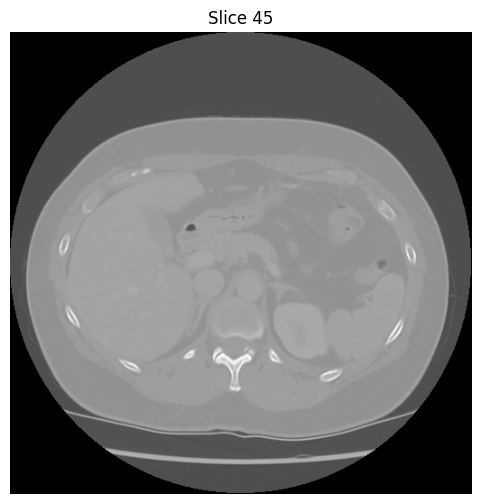

In [9]:
middle = ct_array.shape[0] // 2

plt.figure(figsize=(6,6))

plt.imshow(ct_array[middle], cmap="gray")

plt.title(f"Slice {middle}")

plt.axis("off")

plt.show()

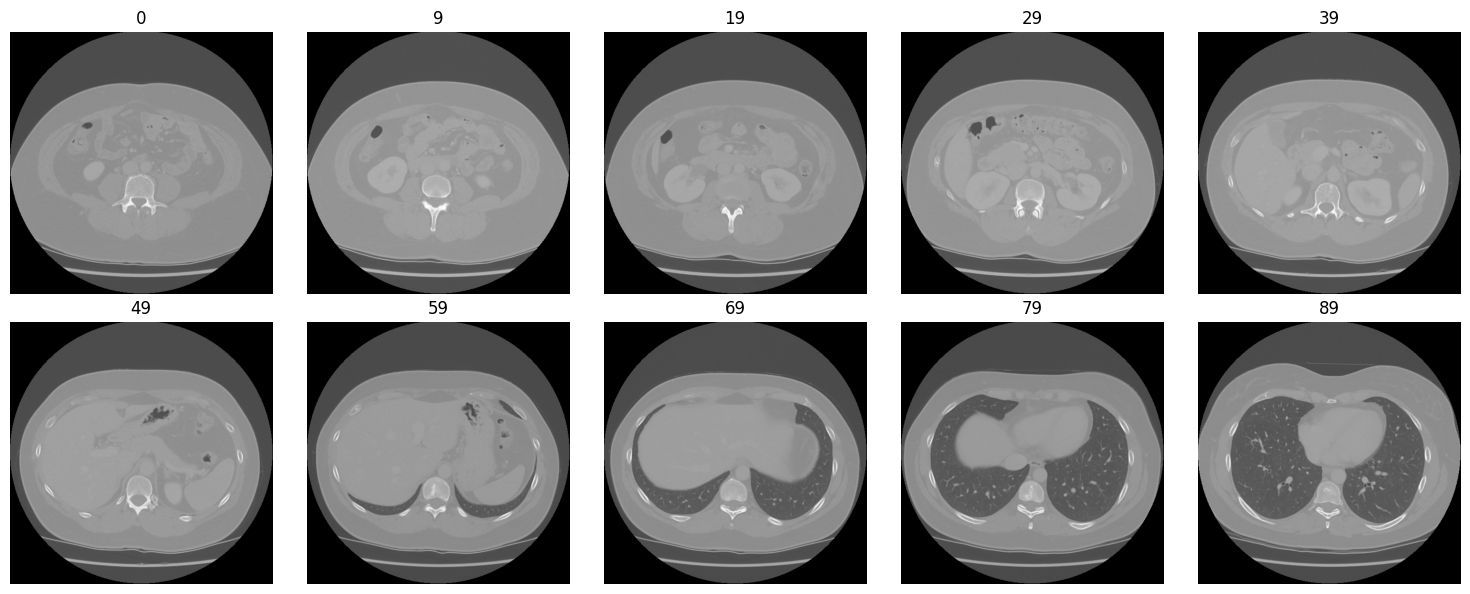

In [10]:
fig, axes = plt.subplots(2,5, figsize=(15,6))

indices = np.linspace(
    0,
    ct_array.shape[0]-1,
    10,
    dtype=int
)

for ax, idx in zip(axes.flat, indices):

    ax.imshow(ct_array[idx], cmap="gray")

    ax.set_title(idx)

    ax.axis("off")

plt.tight_layout()

plt.show()

In [11]:
def window_image(img, level=50, width=350):

    lower = level - width//2
    upper = level + width//2

    return np.clip(img, lower, upper)

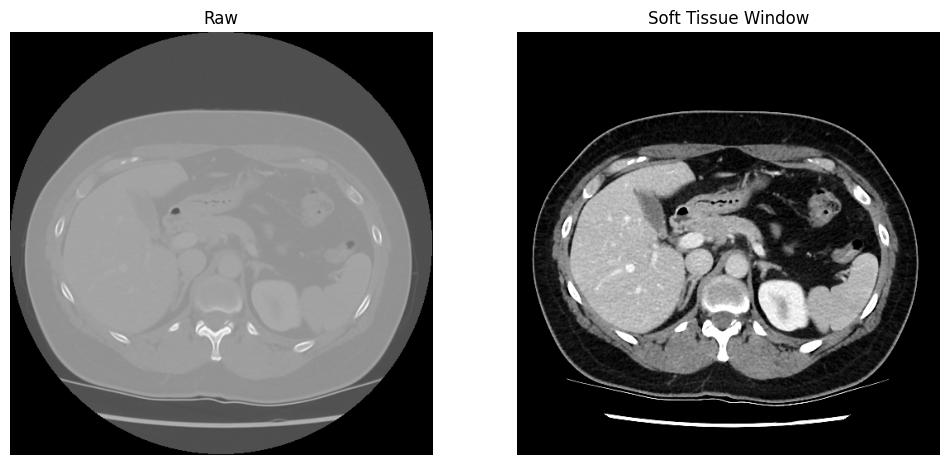

In [12]:
windowed = window_image(ct_array)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)

plt.imshow(ct_array[middle], cmap="gray")

plt.title("Raw")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(windowed[middle], cmap="gray")

plt.title("Soft Tissue Window")

plt.axis("off")

plt.show()

In [13]:
mask_path = AUTO_LABEL_DIR / patient.name

print(mask_path.exists())

False


In [14]:
print("First 10 automatic label files:\n")

for f in auto_masks[:10]:
    print(f.name)

First 10 automatic label files:

100000_00001.nii.gz
100001_00001.nii.gz
100003_00001.nii.gz
100004_00001.nii.gz
100005_00001.nii.gz
100006_00001.nii.gz
100007_00001.nii.gz
100008_00001.nii.gz
100010_00001.nii.gz
100011_00001.nii.gz


In [15]:
print("CT file:")
print(patient.name)

CT file:
100000_00001_0000.nii.gz


In [16]:
print("CT:", patient.name)
print()

print("Automatic labels containing patient ID:")

patient_id = patient.name.split("_")[0]

matches = [f.name for f in auto_masks if patient_id in f.name]

print(matches[:20])

CT: 100000_00001_0000.nii.gz

Automatic labels containing patient ID:
['100000_00001.nii.gz']


In [17]:
ct_filename = patient.name

mask_filename = ct_filename.replace("_0000.nii.gz", ".nii.gz")

print("CT File:   ", ct_filename)
print("Mask File: ", mask_filename)

mask_path = AUTO_LABEL_DIR / mask_filename

print("Exists:", mask_path.exists())

CT File:    100000_00001_0000.nii.gz
Mask File:  100000_00001.nii.gz
Exists: True


In [18]:
mask = sitk.ReadImage(str(mask_path))

mask_array = sitk.GetArrayFromImage(mask)

print("CT shape:  ", ct_array.shape)
print("Mask shape:", mask_array.shape)

CT shape:   (90, 512, 512)
Mask shape: (90, 512, 512)


In [19]:
labels = np.unique(mask_array)

print(labels)

[0. 2. 3. 4. 6.]


In [20]:
pancreas_slices = np.where(np.any(mask_array == 4, axis=(1, 2)))[0]

print("Number of pancreas slices:", len(pancreas_slices))

print("First slice:", pancreas_slices[0])

print("Last slice:", pancreas_slices[-1])

Number of pancreas slices: 38
First slice: 18
Last slice: 55


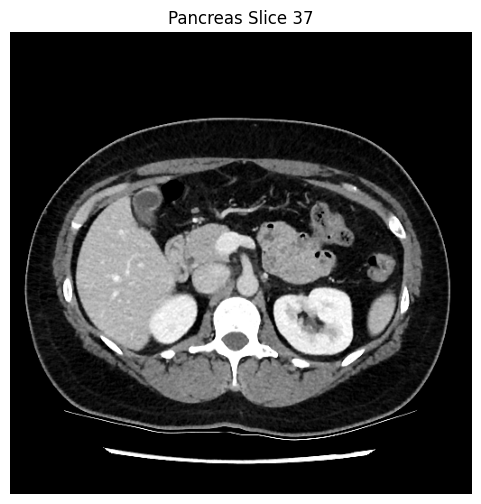

In [21]:
middle_pancreas = pancreas_slices[len(pancreas_slices) // 2]

plt.figure(figsize=(6,6))

plt.imshow(windowed[middle_pancreas], cmap="gray")

plt.title(f"Pancreas Slice {middle_pancreas}")

plt.axis("off")

plt.show()

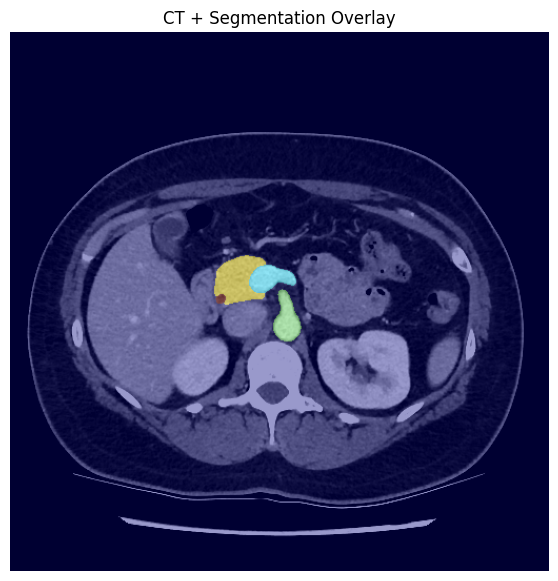

In [22]:
plt.figure(figsize=(7,7))

plt.imshow(windowed[middle_pancreas], cmap="gray")

plt.imshow(
    mask_array[middle_pancreas],
    alpha=0.4,
    cmap="jet"
)

plt.title("CT + Segmentation Overlay")

plt.axis("off")

plt.show()

In [23]:
print("Contains PDAC lesion:", 1 in labels)

Contains PDAC lesion: False


In [24]:
pdac_cases = metadata[metadata["label"] == "PDAC"]

print("Number of PDAC cases:", len(pdac_cases))

pdac_cases.head()

Number of PDAC cases: 676


,PANORAMA_patient_id,PANORAMA_study_id,anonymized_study_date,patient_age,patient_sex,scanner,label,level
2,100002,100002_00001,2021-03-02,077Y,F,TOSHIBA,PDAC,pathology
3,100003,100003_00001,2016-12-28,057Y,M,TOSHIBA,PDAC,cytology
5,100005,100005_00001,2019-03-01,073Y,F,TOSHIBA,PDAC,cytology
9,100009,100009_00001,NaT,NaN,NaN,NaN,PDAC,MSD_dataset
11,100011,100011_00001,2022-08-28,065Y,M,SIEMENS,PDAC,pathology


In [25]:
study_id = pdac_cases.iloc[0]["PANORAMA_study_id"]

print(study_id)

100002_00001


In [26]:
ct_file = CT_DIR / f"{study_id}_0000.nii.gz"

mask_file = AUTO_LABEL_DIR / f"{study_id}.nii.gz"

print(ct_file.exists())

print(mask_file.exists())

True
False


In [27]:
ct = sitk.ReadImage(str(ct_file))
mask = sitk.ReadImage(str(mask_file))

ct_array = sitk.GetArrayFromImage(ct)
mask_array = sitk.GetArrayFromImage(mask)

windowed = window_image(ct_array)

RuntimeError: Exception thrown in SimpleITK ImageFileReader_Execute: D:\a\SimpleITK\SimpleITK\Code\IO\src\sitkImageReaderBase.cxx:91:
sitk::ERROR: The file "D:\Pancreatic_Cancer_Thesis\data\labels\Automatic_Labels\100002_00001.nii.gz" does not exist.

In [ ]:
# Get all CT study IDs in Batch 1
ct_study_ids = {
    f.name.replace("_0000.nii.gz", "")
    for f in ct_files
}

print("CT studies in Batch 1:", len(ct_study_ids))

CT studies in Batch 1: 557


In [ ]:
batch1_pdac = metadata[
    (metadata["label"] == "PDAC") &
    (metadata["PANORAMA_study_id"].isin(ct_study_ids))
]

print("PDAC cases in Batch 1:", len(batch1_pdac))

batch1_pdac.head()

PDAC cases in Batch 1: 158


,PANORAMA_patient_id,PANORAMA_study_id,anonymized_study_date,patient_age,patient_sex,scanner,label,level
2,100002,100002_00001,2021-03-02,077Y,F,TOSHIBA,PDAC,pathology
3,100003,100003_00001,2016-12-28,057Y,M,TOSHIBA,PDAC,cytology
5,100005,100005_00001,2019-03-01,073Y,F,TOSHIBA,PDAC,cytology
9,100009,100009_00001,NaT,NaN,NaN,NaN,PDAC,MSD_dataset
11,100011,100011_00001,2022-08-28,065Y,M,SIEMENS,PDAC,pathology


In [ ]:
study_id = batch1_pdac.iloc[0]["PANORAMA_study_id"]

print(study_id)

100002_00001


In [ ]:
ct_file = CT_DIR / f"{study_id}_0000.nii.gz"
mask_file = AUTO_LABEL_DIR / f"{study_id}.nii.gz"

print("CT:", ct_file.exists())
print("Mask:", mask_file.exists())

CT: True
Mask: False


In [ ]:
manual_file = MANUAL_LABEL_DIR / f"{study_id}.nii.gz"

print("Manual:", manual_file.exists())

Manual: True


In [ ]:
def get_mask_path(study_id):
    """
    Returns the path to the segmentation mask.
    Preference:
        1. Manual label
        2. Automatic label
    """

    manual = MANUAL_LABEL_DIR / f"{study_id}.nii.gz"

    if manual.exists():
        return manual, "Manual"

    automatic = AUTO_LABEL_DIR / f"{study_id}.nii.gz"

    if automatic.exists():
        return automatic, "Automatic"

    return None, None

In [ ]:
mask_path, mask_type = get_mask_path(study_id)

print(mask_path)
print(mask_type)

D:\Pancreatic_Cancer_Thesis\data\labels\Manual_Labels\100002_00001.nii.gz
Manual


In [ ]:
ct = sitk.ReadImage(str(ct_file))
mask = sitk.ReadImage(str(mask_path))

ct_array = sitk.GetArrayFromImage(ct)
mask_array = sitk.GetArrayFromImage(mask)

windowed = window_image(ct_array)

print(ct_array.shape)
print(mask_array.shape)

(561, 512, 512)
(561, 512, 512)


In [ ]:
labels = np.unique(mask_array)

print("Labels found:", labels)

Labels found: [0. 1. 2. 3. 4. 5. 6.]


In [ ]:
tumor_slices = np.where(
    np.any(mask_array == 1, axis=(1, 2))
)[0]

print("Tumor slices:", len(tumor_slices))
print(tumor_slices)

Tumor slices: 56
[269 270 271 272 273 274 275 276 277 278 279 280 281 282 283 284 285 286
 287 288 289 290 291 292 293 294 295 296 297 298 299 300 301 302 303 304
 305 306 307 308 309 310 311 312 313 314 315 316 317 318 319 320 321 322
 323 324]


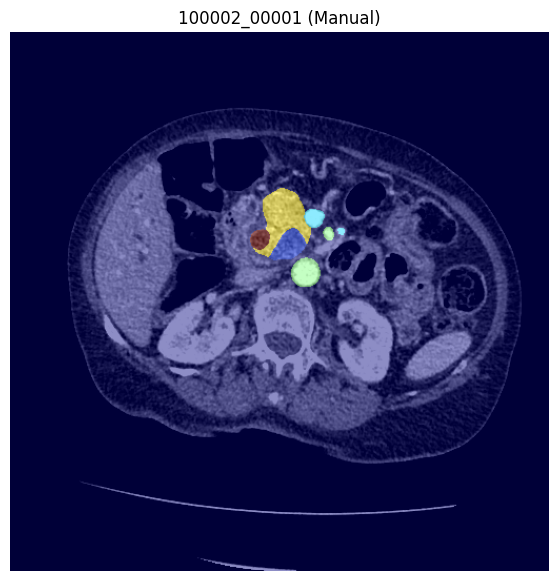

In [ ]:
middle = tumor_slices[len(tumor_slices) // 2]

plt.figure(figsize=(7, 7))

plt.imshow(windowed[middle], cmap="gray")

plt.imshow(
    mask_array[middle],
    alpha=0.45,
    cmap="jet"
)

plt.title(f"{study_id} ({mask_type})")

plt.axis("off")

plt.show()

In [ ]:
from pathlib import Path

ct_files = sorted(Path(r"D:\Pancreatic_Cancer_Thesis\data\raw_ct").glob("*.nii.gz"))

print("Number of CT files:", len(ct_files))

print("First 5 files:")
for f in ct_files[:5]:
    print(f.name)

print("\nLast 5 files:")
for f in ct_files[-5:]:
    print(f.name)

Number of CT files: 557
First 5 files:
100000_00001_0000.nii.gz
100001_00001_0000.nii.gz
100002_00001_0000.nii.gz
100003_00001_0000.nii.gz
100004_00001_0000.nii.gz

Last 5 files:
100542_00001_0000.nii.gz
100543_00001_0000.nii.gz
100544_00001_0000.nii.gz
100545_00001_0000.nii.gz
101381_00001_0000.nii.gz


In [ ]:
study_id = ct_files[0].name.replace("_0000.nii.gz", "")

print(study_id)

100000_00001


In [ ]:
case = load_case(study_id)

print(case["mask_type"])
print(case["ct_array"].shape)
print(case["mask_array"].shape)

Automatic
(90, 512, 512)
(90, 512, 512)


In [ ]:
import importlib
import src.io

importlib.reload(src.io)

from src.io import *

print("Reloaded!")

Reloaded!


In [ ]:
from src.io import *

print("Project root:", PROJECT_ROOT)
print("Number of CT cases:", len(list_ct_cases()))

case = load_case("100000_00001")

print(case["study_id"])
print(case["mask_type"])
print(case["ct_array"].shape)
print(case["mask_array"].shape)
print(case["spacing"])

Project root: D:\Pancreatic_Cancer_Thesis
Number of CT cases: 557
100000_00001
Automatic
(90, 512, 512)
(90, 512, 512)
(0.6949999928474426, 0.6949999928474426, 2.3999998569488525)


In [ ]:
from src.io import list_ct_cases

study_ids = list_ct_cases()

print("Total cases:", len(study_ids))
print("101159_00001" in study_ids)

Total cases: 557
False


In [ ]:
from src.io import list_ct_cases, load_case

study_ids = list_ct_cases()

print(study_ids[:10])

case = load_case(study_ids[0])

print(case["study_id"])

['100000_00001', '100001_00001', '100002_00001', '100003_00001', '100004_00001', '100005_00001', '100006_00001', '100007_00001', '100008_00001', '100009_00001']
100000_00001


In [ ]:
from pathlib import Path

metadata_dir = Path(r"D:\Pancreatic_Cancer_Thesis\data\metadata")

print("Exists:", metadata_dir.exists())

print("\nFiles:")
for f in metadata_dir.iterdir():
    print(f.name)

Exists: True

Files:
clinical_information.xlsx
generated


In [ ]:
from src.io import DATA_DIR
import pandas as pd

metadata = pd.read_excel(
    DATA_DIR / "metadata" / "clinical_information.xlsx"
)

print(metadata.head())

   PANORAMA_patient_id PANORAMA_study_id anonymized_study_date patient_age  \
0               100000      100000_00001            2018-10-04        042Y   
1               100001      100001_00001            2014-04-24        068Y   
2               100002      100002_00001            2021-03-02        077Y   
3               100003      100003_00001            2016-12-28        057Y   
4               100004      100004_00001            2018-02-09        068Y   

  patient_sex  scanner     label      level  
0           F  TOSHIBA  non-PDAC  radiology  
1           M  SIEMENS  non-PDAC  radiology  
2           F  TOSHIBA      PDAC  pathology  
3           M  TOSHIBA      PDAC   cytology  
4           M  SIEMENS  non-PDAC  radiology  


In [ ]:
from importlib import reload
import src.io

reload(src.io)

from src.io import *

print_dataset_summary()

print()

print(case_exists("100000_00001"))

print()

case = random_case()

print(case["study_id"])
print(case["mask_type"])

print()

pdac = random_case("PDAC")

print(pdac["study_id"])

PANORAMA Dataset
CT volumes          : 557
Manual labels       : 482
Automatic labels    : 1756
Metadata rows       : 2238

True

100273_00001
Automatic

100368_00001


In [28]:
from importlib import reload

import src.visualization

reload(src.visualization)

from src.visualization import *
from src.io import *

In [29]:
case = load_case("100000_00001")

print_case_info(case)

100000_00001
Mask: Automatic
Shape: (90, 512, 512)
Spacing: (0.6949999928474426, 0.6949999928474426, 2.3999998569488525)
Origin: (-181.6833038330078, -177.777099609375, 1759.4000244140625)


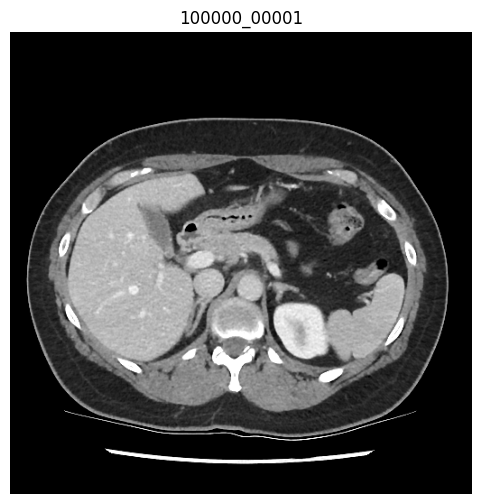

In [30]:
show_middle_slice(case)

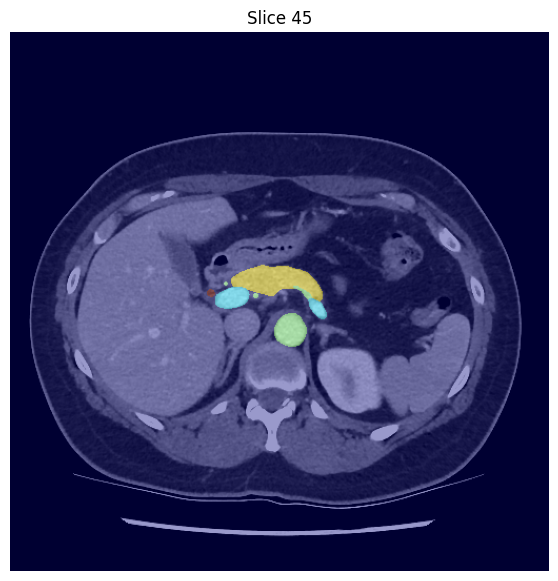

In [31]:
show_case(case)

100513_00001
Mask: Automatic
Shape: (103, 512, 512)
Spacing: (0.775390625, 0.775390625, 4.0)
Origin: (-194.1123046875, -340.1123046875, 34.5)


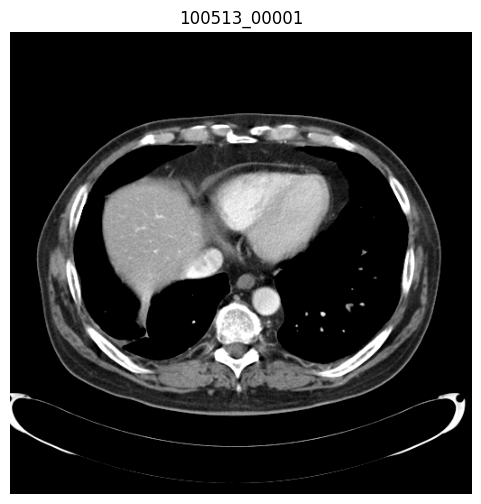

In [32]:
show_random_case()

100180_00001
Mask: Automatic
Shape: (232, 512, 512)
Spacing: (0.69921875, 0.69921875, 1.0)
Origin: (-196.89999389648438, -56.95000076293945, 156.66000366210938)


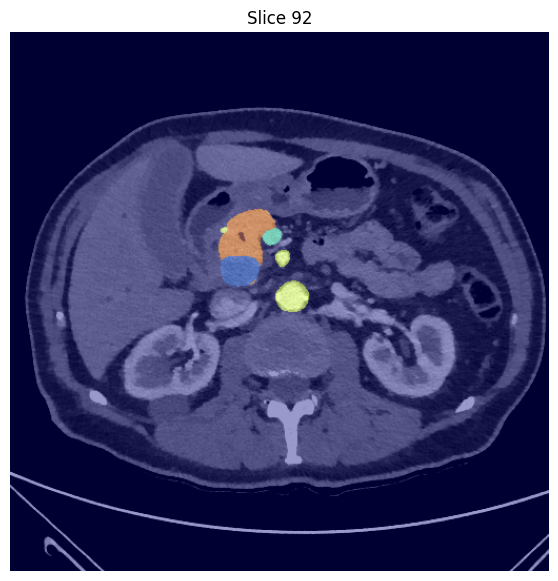

In [33]:
show_random_case("PDAC")